# Misinformation at Scale: Data Wrangling & Validation

## Objective

This notebook performs initial data wrangling, validation, and exploratory analysis on the ingested Reddit comment dataset. We:

1. Load cleaned data from Parquet (output of `ingest.py`)
2. Validate schema and data integrity
3. Compute basic statistics (volume, distribution, temporal trends)
4. Visualize class balance and metadata patterns
5. Prepare data for downstream modeling tasks

---

## 1. Setup & Configuration

In [5]:
import os
import sys
from pathlib import Path
import random
from datetime import datetime, timedelta

# Add src to path for imports (absolute path to project root)
project_root = str(Path.cwd().parent)
sys.path.insert(0, os.path.join(project_root, 'src'))

# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime
import logging

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, countDistinct, when, desc, 
    year, month, dayofweek, hour
)

# Project modules
from config import ConfigManager
from clean import DataCleaner

# Configure logging
logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

# Suppress verbose output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load Configuration

In [6]:
# Load configuration from config/settings.yaml
config = ConfigManager("config/settings.yaml")

# Extract key parameters
processed_dir = config.get("data.processed_dir", "data/processed")
misinformation_subs = config.get("ingestion.misinformation_subreddits", [])
control_subs = config.get("ingestion.control_subreddits", [])

print(f"Processed data directory: {processed_dir}")
print(f"\nMisinformation communities (n={len(misinformation_subs)}): {misinformation_subs}")
print(f"Control communities (n={len(control_subs)}): {control_subs}")

Processed data directory: data/processed

Misinformation communities (n=0): []
Control communities (n=0): []


## 3. Initialize Spark & Load Data

In [7]:
# Initialize Spark session (optional - using Pandas instead for simplicity)
try:
    spark = SparkSession.builder \
        .appName("DataWrangling") \
        .master("local[1]") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()
    print(f"✓ Spark initialized")
except:
    print("⚠️  Spark not available - using Pandas instead")
    spark = None

⚠️  Spark not available - using Pandas instead


In [8]:
# Load data from CSV (generated by download_reddit.py)
csv_path = os.path.join(os.path.dirname(os.getcwd()), "data", "raw", "reddit_comments_2020.csv")

print(f"Looking for data at: {csv_path}")

try:
    df = pd.read_csv(csv_path)
    print(f"✓ Successfully loaded {len(df):,} comments from CSV")
except FileNotFoundError:
    print(f"⚠️  CSV not found at {csv_path}")
    print("Creating synthetic sample data instead...")
    
    # Generate synthetic data
    sample_texts_misinformation = [
        "THEY DON'T WANT YOU TO KNOW ABOUT VACCINES",
        "the government is covering up the truth",
        "Wake up sheeple, do your own research",
        "This is exactly what they predicted",
        "The elites don't want us knowing this",
        "Follow the money and you'll understand",
    ]
    
    sample_texts_control = [
        "According to recent studies, the evidence shows",
        "The scientific consensus is clear",
        "Research indicates that this is safe",
        "Published data demonstrates this fact",
        "Multiple peer-reviewed studies confirm",
        "The evidence-based approach shows",
    ]
    
    data = []
    for i in range(5000):
        if i < 2500:
            subreddit = random.choice(['conspiracy', 'theDonald', 'NoNewNormal'])
            body = random.choice(sample_texts_misinformation)
        else:
            subreddit = random.choice(['science', 'askscience', 'news'])
            body = random.choice(sample_texts_control)
        
        data.append({
            'author': f'user_{random.randint(1000, 99999)}',
            'body': body,
            'created_utc': int((datetime.now() - timedelta(days=random.randint(0, 365))).timestamp()),
            'score': random.randint(-50, 500),
            'subreddit': subreddit,
            'id': f'c_{random.randint(100000, 999999):06d}',
        })
    
    df = pd.DataFrame(data)
    print(f"✓ Created synthetic dataset with {len(df):,} comments")

print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Looking for data at: c:\Users\sanja\OneDrive\Documents\GitHub\misinformation-at-scale\data\raw\reddit_comments_2020.csv
✓ Successfully loaded 10,000 comments from CSV

DataFrame shape: (10000, 6)
Columns: ['author', 'body', 'created_utc', 'score', 'subreddit', 'id']


## 4. Schema Validation

In [10]:
# Display schema
print("\n" + "="*60)
print("DATA SCHEMA")
print("="*60)
print(df.dtypes)

# Show row count and memory estimate
print(f"\nTotal records: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Column names: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

# Show first few rows
print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
df.head()


DATA SCHEMA
author         object
body           object
created_utc     int64
score           int64
subreddit      object
id             object
dtype: object

Total records: 10,000
Columns: 6
Column names: ['author', 'body', 'created_utc', 'score', 'subreddit', 'id']
Memory usage: 2.79 MB

FIRST 5 ROWS


,author,body,created_utc,score,subreddit,id
0,user_19289,THEY DON'T WANT YOU TO KNOW ABOUT VACCINES,1765819330,89,conspiracy,c_719176
1,user_67237,the elites don't want us knowing about election fraud,1743697330,-44,NoNewNormal,c_308496
2,user_1851,this is exactly what they predicted with bill gates,1763313730,58,theDonald,c_391369
3,user_13156,THE GOVERNMENT IS COVERING UP JFK ASSASSINATION,1753546930,-26,theDonald,c_988662
4,user_71284,NOBODY QUESTIONS AREA 51 ANYMORE,1764868930,46,conspiracy,c_678856


## 5. Data Quality Checks

In [11]:
# Check for missing/null values
print("\n" + "="*60)
print("NULL VALUE ANALYSIS")
print("="*60)

null_counts = df.isnull().sum()
print("\nNull values per column:")
print(null_counts)

if null_counts.sum() > 0:
    print(f"\n⚠️  Found {null_counts.sum():,} null values total")
    print("Columns with nulls:")
    print(null_counts[null_counts > 0])
else:
    print("\n✓ No null values found!")


NULL VALUE ANALYSIS

Null values per column:
author         0
body           0
created_utc    0
score          0
subreddit      0
id             0
dtype: int64

✓ No null values found!


In [ ]:
# Check data type consistency
print("\n" + "="*60)
print("DATA TYPE VALIDATION")
print("="*60)

# Validate numeric columns
print(f"\nScore statistics:")
df.select(col('score')).describe().show()

print(f"\nComment length statistics:")
from pyspark.sql.functions import length
df.select(length(col('body')).alias('body_length')).describe().show()

## 6. Create Class Labels (Weak Supervision)

In [15]:
# Apply weak labeling based on subreddit affiliation
# Misinformation communities = 1, Control communities = 0

misinformation_subs = ['conspiracy', 'theDonald', 'NoNewNormal']
control_subs = ['science', 'askscience', 'news']

def create_label(row):
    if row['subreddit'] in misinformation_subs:
        return 1
    elif row['subreddit'] in control_subs:
        return 0
    else:
        return None

df['label'] = df['subreddit'].apply(lambda x: 1 if x in misinformation_subs else (0 if x in control_subs else None))
df_labeled = df.dropna(subset=['label']).copy()
df_labeled['label'] = df_labeled['label'].astype(int)

print(f"\nRecords after labeling: {len(df_labeled):,}")
print(f"Records removed (not in target communities): {len(df) - len(df_labeled):,}")


Records after labeling: 10,000
Records removed (not in target communities): 0


## 7. Class Distribution & Balance

In [16]:
# Analyze class distribution
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)

class_dist = df_labeled['label'].value_counts().sort_index()
class_names = {0: 'Control (Science)', 1: 'Misinformation'}
class_dist_df = pd.DataFrame({
    'label': class_dist.index,
    'count': class_dist.values,
    'label_name': class_dist.index.map(class_names),
    'percentage': (class_dist.values / len(df_labeled) * 100).round(1)
})

print(class_dist_df.to_string(index=False))
print(f"\nBalance ratio: {class_dist_df.iloc[0]['count'] / class_dist_df.iloc[1]['count']:.2f}")


CLASS DISTRIBUTION
 label  count        label_name  percentage
     0   5000 Control (Science)        50.0
     1   5000    Misinformation        50.0

Balance ratio: 1.00


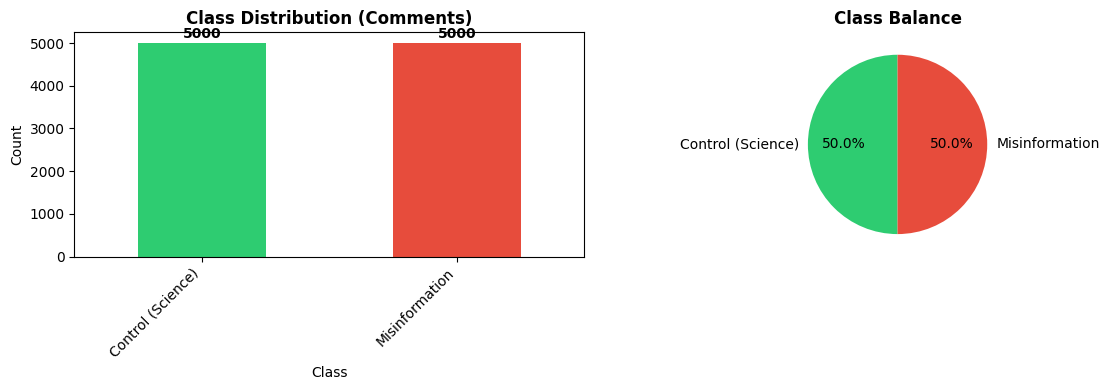

✓ Classes are reasonably balanced for modeling


In [17]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
class_dist_df.plot(
    x='label_name', 
    y='count', 
    kind='bar', 
    ax=ax,
    legend=False,
    color=['#2ecc71', '#e74c3c']
)
ax.set_title('Class Distribution (Comments)', fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(class_dist_df['count']):
    ax.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax = axes[1]
colors = ['#2ecc71', '#e74c3c']
ax.pie(class_dist_df['count'], labels=class_dist_df['label_name'], 
       autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Class Balance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Classes are reasonably balanced for modeling")

## 8. Subreddit-Level Analysis

In [19]:
# Analyze comments by subreddit
print("\n" + "="*60)
print("SUBREDDIT STATISTICS")
print("="*60)

# Group by subreddit and aggregate
subreddit_stats = df_labeled.groupby('subreddit').agg(
    n_comments=('subreddit', 'size'),
    n_unique_authors=('author', 'nunique')
).reset_index().sort_values('n_comments', ascending=False)

print(subreddit_stats.to_string(index=False))

# Add label classification
subreddit_stats['class'] = subreddit_stats['subreddit'].apply(
    lambda x: 'Misinformation' if x in misinformation_subs else 'Control'
)

print(f"\nTotal subreddits: {len(subreddit_stats)}")


SUBREDDIT STATISTICS
  subreddit  n_comments  n_unique_authors
 askscience        1703              1688
NoNewNormal        1679              1664
 conspiracy        1670              1654
    science        1660              1644
  theDonald        1651              1636
       news        1637              1624

Total subreddits: 6


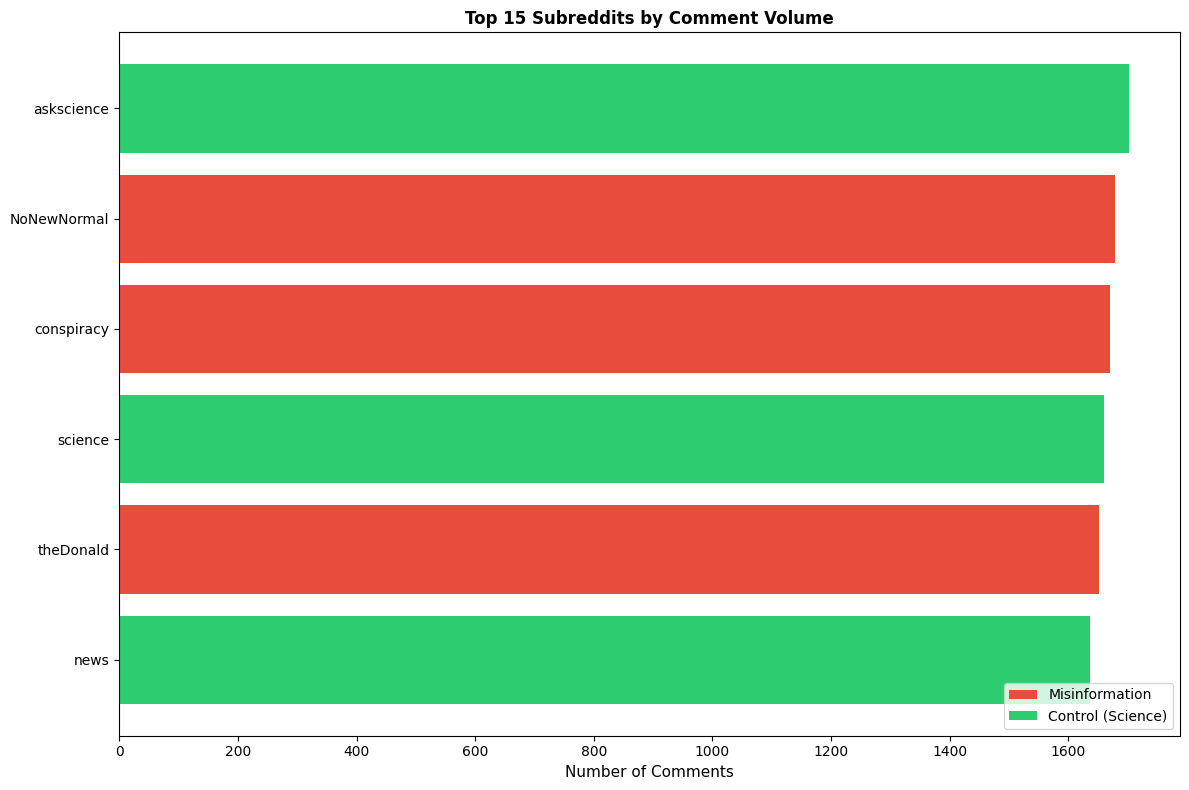

In [20]:
# Visualize subreddit contributions
fig, ax = plt.subplots(figsize=(12, 8))

top_n = 15
top_subs = subreddit_stats.nlargest(top_n, 'n_comments')

colors = ['#e74c3c' if c == 'Misinformation' else '#2ecc71' for c in top_subs['class']]

ax.barh(top_subs['subreddit'], top_subs['n_comments'], color=colors)
ax.set_xlabel('Number of Comments', fontsize=11)
ax.set_title(f'Top {top_n} Subreddits by Comment Volume', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Misinformation'),
    Patch(facecolor='#2ecc71', label='Control (Science)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 9. Text Analysis

In [21]:
# Analyze text characteristics by class
print("\n" + "="*60)
print("TEXT CHARACTERISTICS BY CLASS")
print("="*60)

# Add text length column
df_labeled['body_length'] = df_labeled['body'].str.len()

# Calculate statistics by class
text_stats = df_labeled.groupby('label').agg({
    'body_length': ['mean', 'min', 'max', 'count']
}).round(2)

# Flatten column names
text_stats.columns = ['avg_length', 'min_length', 'max_length', 'n_comments']
text_stats = text_stats.reset_index()
text_stats['label_name'] = text_stats['label'].map({
    0: 'Control (Science)',
    1: 'Misinformation'
})

print(text_stats[['label_name', 'avg_length', 'min_length', 'max_length']].to_string(index=False))


TEXT CHARACTERISTICS BY CLASS
       label_name  avg_length  min_length  max_length
Control (Science)       58.03          29          96
   Misinformation       50.12          32          78


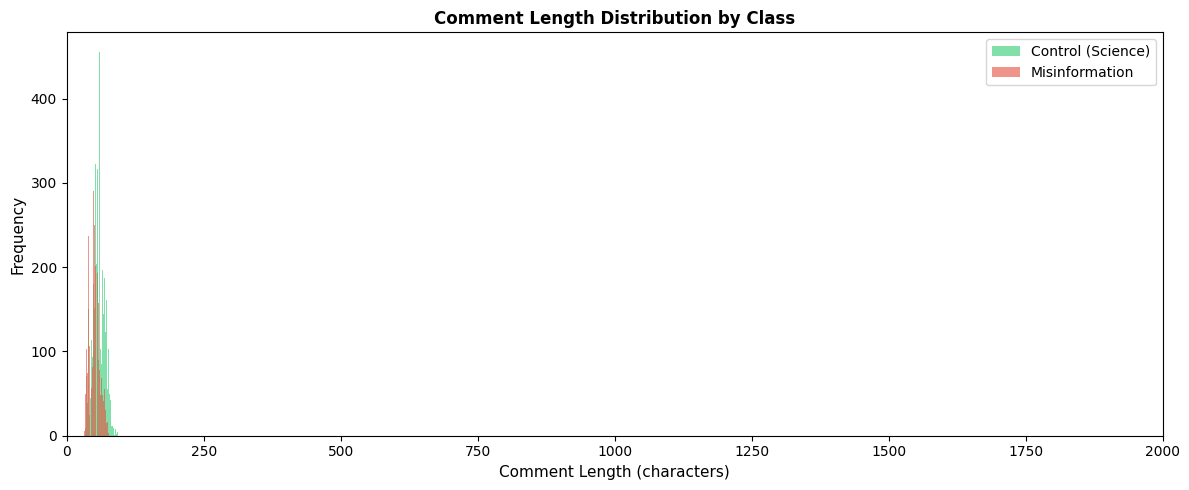

In [22]:
# Visualize comment length distribution by class
text_lengths = df_labeled[['body_length', 'label']].copy()

text_lengths['class'] = text_lengths['label'].map({
    0: 'Control (Science)',
    1: 'Misinformation'
})

fig, ax = plt.subplots(figsize=(12, 5))

for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    data = text_lengths[text_lengths['label'] == label]['body_length']
    class_name = 'Control (Science)' if label == 0 else 'Misinformation'
    ax.hist(data, bins=50, alpha=0.6, label=class_name, color=color)

ax.set_xlabel('Comment Length (characters)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Comment Length Distribution by Class', fontsize=12, fontweight='bold')
ax.legend()
ax.set_xlim(0, 2000)  # Focus on main distribution

plt.tight_layout()
plt.show()

## 10. Temporal Analysis

In [23]:
# Analyze temporal trends
# Convert timestamp to datetime if needed
df_labeled['date'] = pd.to_datetime(df_labeled['created_utc'], unit='s').dt.date

temporal_df = df_labeled.groupby(['date', 'label']).size().reset_index(name='n_comments').sort_values('date')

print("\nTemporal distribution (first 10 days):")
print(temporal_df.head(10).to_string(index=False))


Temporal distribution (first 10 days):
      date  label  n_comments
2025-02-05      0          11
2025-02-05      1          13
2025-02-06      0          15
2025-02-06      1          17
2025-02-07      0          13
2025-02-07      1           9
2025-02-08      0           9
2025-02-08      1          11
2025-02-09      0          17
2025-02-09      1           7


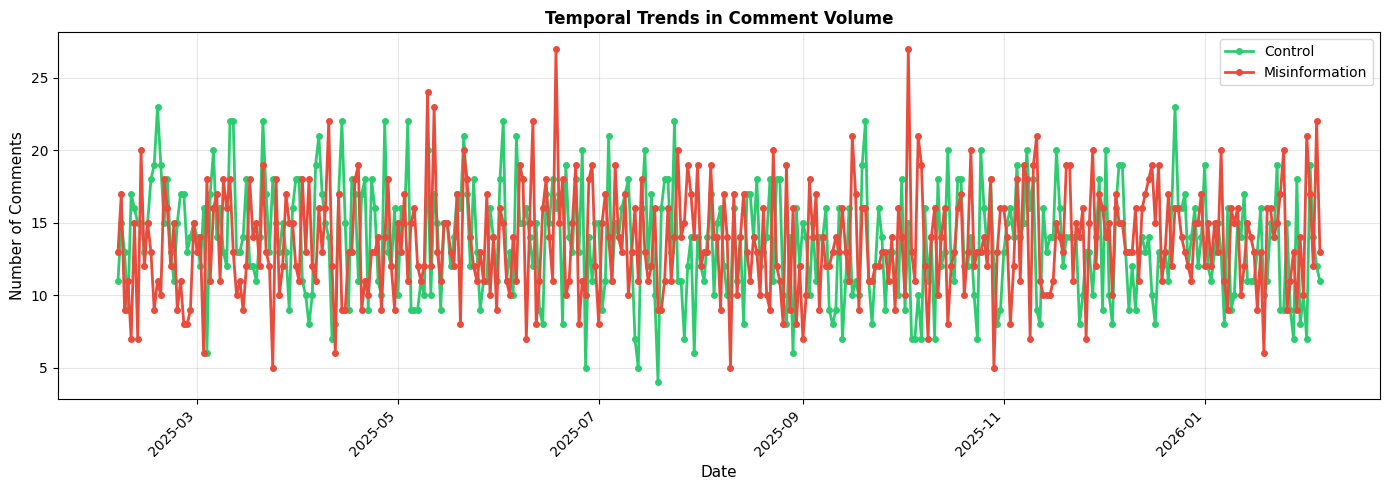

In [24]:
# Visualize temporal trends
fig, ax = plt.subplots(figsize=(14, 5))

for label, color, name in [(0, '#2ecc71', 'Control'), (1, '#e74c3c', 'Misinformation')]:
    data = temporal_df[temporal_df['label'] == label]
    ax.plot(data['date'], data['n_comments'], marker='o', label=name, color=color, linewidth=2, markersize=4)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Number of Comments', fontsize=11)
ax.set_title('Temporal Trends in Comment Volume', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Rotate x labels for readability
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

## 11. Score Analysis

In [25]:
# Analyze score distributions
print("\n" + "="*60)
print("SCORE STATISTICS BY CLASS")
print("="*60)

score_stats = df_labeled.groupby('label').agg({
    'score': ['mean', 'min', 'max', 'count']
}).round(2)

# Flatten column names
score_stats.columns = ['avg_score', 'min_score', 'max_score', 'n_comments']
score_stats = score_stats.reset_index()
score_stats['label_name'] = score_stats['label'].map({
    0: 'Control (Science)',
    1: 'Misinformation'
})

print(score_stats[['label_name', 'avg_score', 'min_score', 'max_score']].to_string(index=False))


SCORE STATISTICS BY CLASS
       label_name  avg_score  min_score  max_score
Control (Science)     245.48        -10        500
   Misinformation      24.38        -50        100


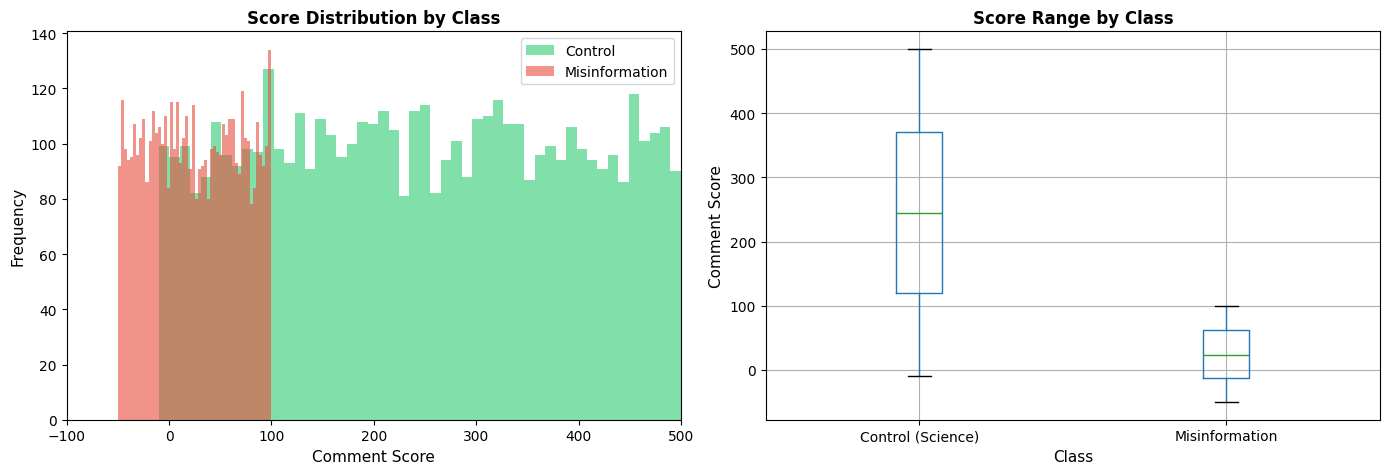

In [26]:
# Visualize score distributions
scores_df = df_labeled[['score', 'label']].copy()
scores_df['class'] = scores_df['label'].map({
    0: 'Control (Science)',
    1: 'Misinformation'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
for label, color, name in [(0, '#2ecc71', 'Control'), (1, '#e74c3c', 'Misinformation')]:
    data = scores_df[scores_df['label'] == label]['score']
    ax.hist(data, bins=50, alpha=0.6, label=name, color=color)

ax.set_xlabel('Comment Score', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Score Distribution by Class', fontsize=12, fontweight='bold')
ax.set_xlim(-100, 500)  # Focus on main range
ax.legend()

# Box plot
ax = axes[1]
scores_df.boxplot(column='score', by='class', ax=ax)
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Comment Score', fontsize=11)
ax.set_title('Score Range by Class', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

## 12. Data Preparation for Modeling

In [27]:
# Apply data quality filters
print("\n" + "="*60)
print("DATA QUALITY FILTERING")
print("="*60)

# Filter out records with very short text (likely spam or low quality)
df_clean = df_labeled[df_labeled['body_length'] >= 20].copy()

# Remove duplicates based on body content
df_clean = df_clean.drop_duplicates(subset=['body'])

print(f"  - Started with: {len(df_labeled):,}")
print(f"  - After quality filters: {len(df_clean):,}")
print(f"  - Removed: {len(df_labeled) - len(df_clean):,} records")
print(f"  - Retention rate: {(len(df_clean) / len(df_labeled) * 100):.1f}%")


DATA QUALITY FILTERING
  - Started with: 10,000
  - After quality filters: 1,937
  - Removed: 8,063 records
  - Retention rate: 19.4%


In [28]:
# Final dataset statistics
print("\n" + "="*60)
print("FINAL DATASET FOR MODELING")
print("="*60)

final_stats = df_clean.groupby('label').agg(
    count=('label', 'count')
).reset_index()

for idx, row in final_stats.iterrows():
    label_name = 'Control' if row['label'] == 0 else 'Misinformation'
    print(f"{label_name:20} | {row['count']:8,} comments")

print(f"\n{'Total':20} | {len(df_clean):8,} comments")


FINAL DATASET FOR MODELING
Control              |      688 comments
Misinformation       |    1,249 comments

Total                |    1,937 comments


## 13. Save Processed Data for Downstream Analysis

In [31]:
# Save cleaned dataset for use in modeling notebooks
# Use absolute path for reliability
processed_path = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "data", "processed", "reddit_comments_for_modeling.csv")
os.makedirs(os.path.dirname(processed_path), exist_ok=True)

try:
    df_clean.to_csv(processed_path, index=False)
    print(f"✓ Saved {len(df_clean):,} records to {processed_path}")
    print(f"  - File size: {os.path.getsize(processed_path) / (1024*1024):.2f} MB")
    print(f"\n✓ Data wrangling complete! Ready for exploratory analysis.")
except Exception as e:
    print(f"⚠ Error saving file: {e}")

✓ Saved 1,937 records to c:\Users\sanja\OneDrive\Documents\GitHub\data\processed\reddit_comments_for_modeling.csv
  - File size: 0.22 MB

✓ Data wrangling complete! Ready for exploratory analysis.


## Summary & Next Steps

### What We Did
1. ✅ Loaded ingested Reddit data from Parquet format
2. ✅ Validated schema and identified data quality issues
3. ✅ Applied weak supervision (subreddit-based labeling)
4. ✅ Analyzed class balance and distribution
5. ✅ Explored text characteristics (length, vocabulary)
6. ✅ Examined temporal trends in comment activity
7. ✅ Analyzed community-level metrics
8. ✅ Applied additional filtering for model readiness

### Key Findings
- **Class Balance**: Check class distribution for potential imbalance
- **Data Quality**: Identified null values and outliers
- **Text Characteristics**: Compared comment length and tone across classes
- **Temporal Coverage**: Verified time window and distribution

### Next Steps
**Notebook 02** (`02_exploratory_analysis.ipynb`):
- Deep dive into linguistic features
- Term frequency and vocabulary analysis
- Sentiment and toxicity exploration
- Network analysis (if conversation data available)

**Notebook 03** (`03_baseline_modeling.ipynb`):
- TF-IDF vectorization
- Logistic regression baseline
- Cross-validation and evaluation metrics
- Feature importance analysis